In [ ]:
#Baseline Model Rentals

In [22]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [23]:


df = pd.read_csv("../raw_data/rentals.csv")

# Display the first rows
df.head()

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,...,transit_line,transit_distance_min,to_brandenburg_gate_km,kaltmiete_eur_monthly,nebenkosten_eur_monthly,warmmiete_eur_monthly,rent_per_m2_kalt_eur,rent_includes_warmmiete,kaution_months,warmmiete_eur_monthly_usd
0,R000001,2023-12-18,Adlershof,Treptow-Köpenick,medium,52.44391,13.53835,2_room,2,55.1,...,U7,203,13.53,517,281,798,9.37,False,3,861
1,R000002,2021-06-07,Lankwitz,Steglitz-Zehlendorf,medium,52.44035,13.33848,4_room,4,106.6,...,U8,111,8.85,1281,347,1628,12.03,True,3,1758
2,R000003,2022-08-19,Britz,Neukölln,low,52.44825,13.45215,3_room,3,102.5,...,U7,27,9.09,1366,524,1889,13.32,False,1,2041
3,R000004,2025-12-29,Hellersdorf,Marzahn-Hellersdorf,low,52.53063,13.62405,3_room,3,90.5,...,S Ringbahn,167,16.74,469,335,804,5.18,True,2,869
4,R000005,2022-07-18,Wartenberg,Lichtenberg,low,52.58212,13.50497,2_room,2,55.6,...,S Ringbahn,110,11.30,369,260,629,6.64,False,2,679


In [ ]:
#Explore the data

In [ ]:
df.shape

(30000, 30)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         30000 non-null  object 
 1   date_listed                30000 non-null  object 
 2   ortsteil                   30000 non-null  object 
 3   bezirk                     30000 non-null  object 
 4   kiez_premium               30000 non-null  object 
 5   lat                        30000 non-null  float64
 6   lon                        30000 non-null  float64
 7   property_type              30000 non-null  object 
 8   rooms                      30000 non-null  int64  
 9   area_m2                    30000 non-null  float64
 10  floor                      30000 non-null  int64  
 11  total_floors               30000 non-null  int64  
 12  building_era               30000 non-null  object 
 13  energy_class               30000 non-null  obj

In [24]:
df.describe()

,lat,lon,rooms,area_m2,floor,total_floors,transit_distance_min,to_brandenburg_gate_km,kaltmiete_eur_monthly,nebenkosten_eur_monthly,warmmiete_eur_monthly,rent_per_m2_kalt_eur,kaution_months,warmmiete_eur_monthly_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,52.512407,13.390837,2.522667,75.587640,2.479367,4.951267,89.227100,10.106720,946.804133,265.886900,1212.689167,12.123417,2.500200,1309.704800
std,0.063742,0.125544,1.132488,37.465641,1.864499,1.384494,72.848119,4.612213,724.030300,142.681064,829.216366,5.483438,0.669588,895.554965
min,52.357930,13.113280,1.000000,20.000000,0.000000,3.000000,0.000000,0.230000,86.000000,50.000000,148.000000,2.550000,1.000000,160.000000
25%,52.461430,13.299788,2.000000,48.400000,1.000000,4.000000,27.000000,6.650000,458.000000,164.000000,643.000000,8.180000,2.000000,694.000000
50%,52.511570,13.386030,2.000000,68.700000,2.000000,5.000000,75.000000,9.690000,735.000000,237.000000,988.000000,10.780000,3.000000,1067.000000
75%,52.563122,13.480293,3.000000,94.100000,4.000000,6.000000,137.000000,13.210000,1203.000000,332.000000,1532.000000,14.800000,3.000000,1655.000000
max,52.658910,13.707070,5.000000,302.300000,8.000000,8.000000,424.000000,26.090000,7624.000000,1305.000000,8685.000000,46.400000,3.000000,9380.000000


In [25]:
df.isnull().sum().sort_values(ascending=False)

id                           0
date_listed                  0
kaution_months               0
rent_includes_warmmiete      0
rent_per_m2_kalt_eur         0
warmmiete_eur_monthly        0
nebenkosten_eur_monthly      0
kaltmiete_eur_monthly        0
to_brandenburg_gate_km       0
transit_distance_min         0
transit_line                 0
transit_station              0
furnished                    0
has_balcony                  0
has_lift                     0
condition                    0
position                     0
energy_class                 0
building_era                 0
total_floors                 0
floor                        0
area_m2                      0
rooms                        0
property_type                0
lon                          0
lat                          0
kiez_premium                 0
bezirk                       0
ortsteil                     0
warmmiete_eur_monthly_usd    0
dtype: int64

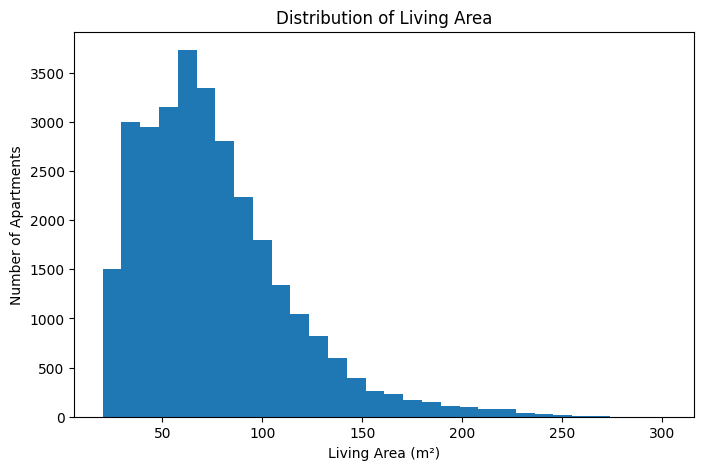

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["area_m2"], bins=30)

plt.title("Distribution of Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Number of Apartments")

plt.show()

In [10]:
df.columns

Index(['id', 'date_listed', 'ortsteil', 'bezirk', 'kiez_premium', 'lat', 'lon',
       'property_type', 'rooms', 'area_m2', 'floor', 'total_floors',
       'building_era', 'energy_class', 'position', 'condition', 'has_lift',
       'has_balcony', 'furnished', 'transit_station', 'transit_line',
       'transit_distance_min', 'to_brandenburg_gate_km',
       'kaltmiete_eur_monthly', 'nebenkosten_eur_monthly',
       'warmmiete_eur_monthly', 'rent_per_m2_kalt_eur',
       'rent_includes_warmmiete', 'kaution_months',
       'warmmiete_eur_monthly_usd'],
      dtype='object')

In [11]:
list(df.columns)

['id',
 'date_listed',
 'ortsteil',
 'bezirk',
 'kiez_premium',
 'lat',
 'lon',
 'property_type',
 'rooms',
 'area_m2',
 'floor',
 'total_floors',
 'building_era',
 'energy_class',
 'position',
 'condition',
 'has_lift',
 'has_balcony',
 'furnished',
 'transit_station',
 'transit_line',
 'transit_distance_min',
 'to_brandenburg_gate_km',
 'kaltmiete_eur_monthly',
 'nebenkosten_eur_monthly',
 'warmmiete_eur_monthly',
 'rent_per_m2_kalt_eur',
 'rent_includes_warmmiete',
 'kaution_months',
 'warmmiete_eur_monthly_usd']

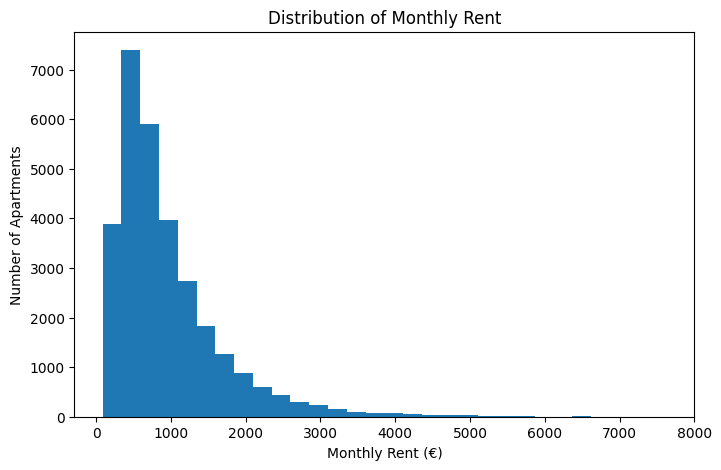

In [12]:
# Distribution of monthly rent

plt.figure(figsize=(8,5))

plt.hist(df["kaltmiete_eur_monthly"], bins=30)

plt.title("Distribution of Monthly Rent")
plt.xlabel("Monthly Rent (€)")
plt.ylabel("Number of Apartments")

plt.show()

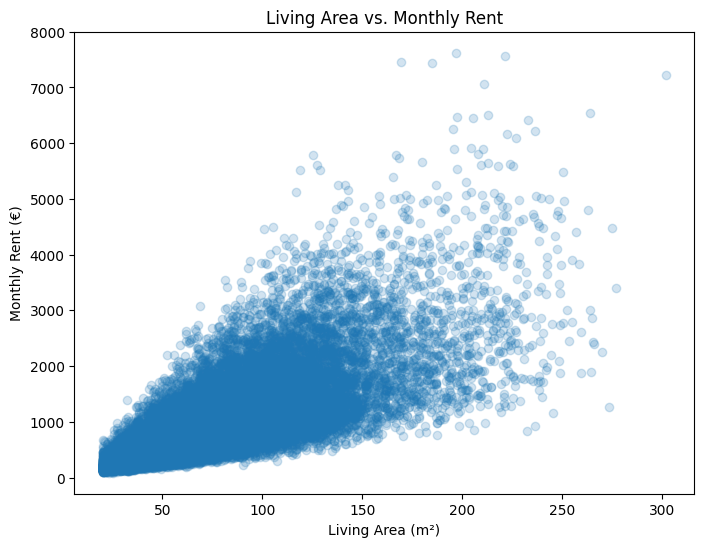

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["area_m2"],
    df["kaltmiete_eur_monthly"],
    alpha=0.2
)

plt.title("Living Area vs. Monthly Rent")
plt.xlabel("Living Area (m²)")
plt.ylabel("Monthly Rent (€)")

plt.show()

In [27]:
X = df[["area_m2"]]
y = df["kaltmiete_eur_monthly"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predict rents

y_pred = model.predict(X_test)

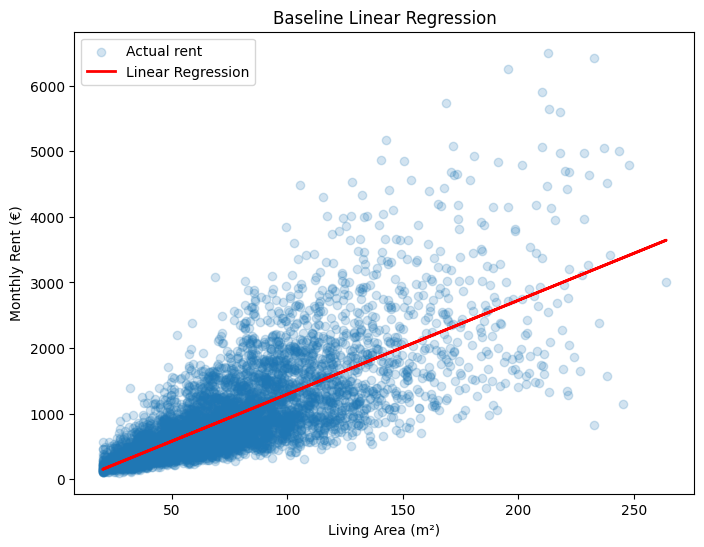

In [31]:
# Plot the regression line

plt.figure(figsize=(8,6))

# Scatter plot of the test data
plt.scatter(
    X_test,
    y_test,
    alpha=0.2,
    label="Actual rent"
)

# Regression line
plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Linear Regression"
)

plt.title("Baseline Linear Regression")
plt.xlabel("Living Area (m²)")
plt.ylabel("Monthly Rent (€)")
plt.legend()

plt.show()

In [21]:
# Evaluate the baseline model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} €")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} €")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error (MAE): 333.32 €
Root Mean Squared Error (RMSE): 495.53 €
R² Score: 0.549
